# Sprint 2 — Extracción de Representaciones y EDA

| Campo | Detalle |
|---|---|
| **Prerequisito** | Sprint 1 completado — `metadata.parquet` y `splits.parquet` existentes |
| **Objetivo** | Extraer eGeMAPSv02 y wav2vec2 sobre audios trimmeados; analizar la geometría del espacio de features |
| **Principio** | Todo EDA supervisado se realiza **exclusivamente sobre el development pool** |

---

## Preguntas que guían este sprint

| # | Pregunta |
|---|---|
| 1 | ¿Las features fueron extraídas para **todos** los audios? |
| 2 | ¿Las dos representaciones están alineadas por `file_id`? |
| 3 | ¿Existen features constantes, NaN o valores infinitos? |
| 4 | ¿Qué estructura muestran las features dentro del development pool? |
| 5 | ¿La geometría está dominada por **emoción**, por **actor** o por ambos? |
| 6 | ¿Cuántos componentes PCA son necesarios para retener el 95% de la varianza? |

---

## Representaciones a extraer

| Representación | Modelo | Dims | Estrategia |
|---|---|---|---|
| **eGeMAPSv02** | openSMILE Functionals | 88 | Features acústicas interpretables (F0, loudness, MFCC, jitter…) |
| **wav2vec2** | `facebook/wav2vec2-base` frozen | 768 | Mean pooling sobre `last_hidden_state`; encoder completamente congelado |

---
## 0 · Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import get_config, resolve_path
from src.utils.reproducibility import set_global_seed
from src.utils.logging import get_logger
from src.utils.io import load_metadata, load_splits
from src.config.contracts import PARTITION_DEVELOPMENT

cfg = get_config()
logger = get_logger("sprint2")
set_global_seed(cfg.seed)

METADATA_PATH = resolve_path(cfg.paths.metadata)
SPLITS_PATH = resolve_path(cfg.paths.splits)
FEATURES_DIR = resolve_path(cfg.paths.features_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

metadata = load_metadata(METADATA_PATH)
splits = load_splits(SPLITS_PATH)

print(f"✅ metadata cargada: {metadata.shape[0]} filas × {metadata.shape[1]} columnas")
print(f"✅ splits cargados: {splits.shape[0]} filas × {splits.shape[1]} columnas")
print(f"Development pool: {(splits['partition'] == PARTITION_DEVELOPMENT).sum()} muestras")

✅ metadata cargada: 1440 filas × 23 columnas
✅ splits cargados: 1440 filas × 4 columnas
Development pool: 864 muestras


---
## 1 · Extracción de eGeMAPSv02

**eGeMAPSv02 Functionals** — 88 features acústicas estadísticas extraídas con openSMILE sobre toda la duración del audio trimmeado.

Las features incluyen estadísticos (media, percentiles, pendiente) de:
- **Prosódicas:** F0 (pitch), loudness, shimmer
- **Calidad vocal:** jitter, HNR, spectral flux
- **Espectrales:** MFCCs (1-4), alpha ratio, Hammarberg index
- **Temporales:** rate of loudness peaks, voiced/unvoiced segments

La extracción usa caché: si `egemaps.parquet` ya existe, lo carga directamente.

In [2]:
from src.features.extract_egemaps import load_or_extract_egemaps

egemaps = load_or_extract_egemaps(
    metadata=metadata,
    output_path=FEATURES_DIR / "egemaps.parquet",
    path_col="file_path_trimmed",
    overwrite=False
)

feat_cols_egem = [c for c in egemaps.columns if c != "file_id"]
print(f"✅ eGeMAPSv02 extraído")
print(f"Shape: {egemaps.shape}")
print(f"Dims: {len(feat_cols_egem)} features")
print(f"Primeras 5: {feat_cols_egem[:5]}")

2026-06-23 16:57:40 | INFO     | src.features.extract_egemaps | Cargando eGeMAPS desde caché: C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\features\egemaps.parquet
✅ eGeMAPSv02 extraído
Shape: (1440, 89)
Dims: 88 features
Primeras 5: ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0']


---
## 2 · Extracción de wav2vec2-base

**`facebook/wav2vec2-base` — encoder congelado, mean pooling.**

Pipeline:
```
Audio trimmed (48kHz)  →  resampleo a 16kHz  →  wav2vec2 encoder (frozen)
  →  last_hidden_state (T × 768)  →  mean pooling  →  vector (768,)
```

El encoder está completamente congelado en esta etapa (Sprint 2). El fine-tuning parcial se explorará en Sprint 3 si los resultados lo justifican.

In [3]:
from src.features.extract_wav2vec import load_or_extract_wav2vec

wav2vec = load_or_extract_wav2vec(
    metadata=metadata,
    output_path=FEATURES_DIR / "wav2vec.parquet",
    path_col="file_path_trimmed",
    model_name=cfg.features.wav2vec.model_name,
    revision=cfg.features.wav2vec.revision,
    target_sample_rate=cfg.audio.target_sample_rate,
    layer=cfg.features.wav2vec.layer,
    pooling=cfg.features.wav2vec.pooling,
    expected_dim=cfg.features.wav2vec.embedding_dim,
    overwrite=False,
)

feat_cols_wav = [c for c in wav2vec.columns if c != "file_id"]
print(f"✅ wav2vec2-base extraído")
print(f"Shape: {wav2vec.shape}")
print(f"Dims: {len(feat_cols_wav)} features (mean pooling)")

C:\Users\franc\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-23 16:57:46 | INFO     | src.features.extract_wav2vec | Cargando wav2vec desde caché: C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\features\wav2vec.parquet
✅ wav2vec2-base extraído
Shape: (1440, 769)
Dims: 768 features (mean pooling)


---
## 3 · Validación de features

Se verifican condiciones bloqueantes antes de proceder al EDA:

In [4]:
def audit_features(df: pd.DataFrame, name: str, expected_n: int) -> None:
    """Verifica integridad del DataFrame de features y reporta claramente."""
    feat_cols = [c for c in df.columns if c != "file_id"]
    X = df[feat_cols].values

    n_nan = int(np.isnan(X).sum())
    n_inf = int(np.isinf(X).sum())
    n_const = int((X.std(axis=0) == 0).sum())
    n_covered = df["file_id"].nunique()

    icon_nan = "✅" if n_nan == 0 else "❌"
    icon_inf = "✅" if n_inf == 0 else "❌"
    icon_cov = "✅" if n_covered == expected_n else "❌"
    icon_const = "✅" if n_const == 0 else "⚠️"

    print(f"── {name} {'─' * (42 - len(name))}")
    print(f"Shape: {X.shape[0]} muestras × {X.shape[1]} features")
    print(f"Cobertura: {n_covered}/{expected_n}  {icon_cov}")
    print(f"NaN: {n_nan}  {icon_nan}")
    print(f"Inf: {n_inf}  {icon_inf}")
    print(f"Constantes : {n_const}  {icon_const}")
    print()

    assert n_nan == 0, f"{name}: NaN detectados ({n_nan})"
    assert n_inf == 0, f"{name}: Inf detectados ({n_inf})"
    assert n_covered == expected_n, f"{name}: cobertura incompleta"

expected = len(metadata)
audit_features(egemaps, "eGeMAPSv02", expected)
audit_features(wav2vec, "wav2vec2-base", expected)

# Alineación por file_id
ids_meta = set(metadata["file_id"])
ids_egem = set(egemaps["file_id"])
ids_wav = set(wav2vec["file_id"])
assert ids_meta == ids_egem == ids_wav, "Desalineación de file_ids"
print("✅ Alineación por file_id: las tres tablas comparten exactamente los mismos IDs.")

── eGeMAPSv02 ────────────────────────────────
Shape: 1440 muestras × 88 features
Cobertura: 1440/1440  ✅
NaN: 0  ✅
Inf: 0  ✅
Constantes : 0  ✅

── wav2vec2-base ─────────────────────────────
Shape: 1440 muestras × 768 features
Cobertura: 1440/1440  ✅
NaN: 0  ✅
Inf: 0  ✅
Constantes : 0  ✅

✅ Alineación por file_id: las tres tablas comparten exactamente los mismos IDs.


---
## 4 · Preparación del development pool

> ⚠️ **Todo el análisis supervisado a continuación se realiza exclusivamente sobre el development pool.** El test nunca se toca en esta etapa.

In [5]:
# Filtrar development pool
dev_ids  = splits[splits["partition"] == PARTITION_DEVELOPMENT]["file_id"]
dev_meta = metadata[metadata["file_id"].isin(dev_ids)].copy()
dev_egem = egemaps[egemaps["file_id"].isin(dev_ids)].copy()
dev_wav2v = wav2vec[wav2vec["file_id"].isin(dev_ids)].copy()

# Merge para análisis supervisado
egem_merged = dev_meta.merge(dev_egem, on="file_id")

# Matrices numéricas alineadas (mismo orden de file_id)
dev_egem_aligned = dev_egem.set_index("file_id").loc[dev_meta["file_id"].values]
dev_wav2v_aligned = dev_wav2v.set_index("file_id").loc[dev_meta["file_id"].values]

X_egem  = dev_egem_aligned.values.astype(np.float32)
X_wav2v = dev_wav2v_aligned.values.astype(np.float32)

y_emo = dev_meta["emotion_original"].values
y_q = dev_meta["emotion_quadrant"].values
y_sex = dev_meta["sex"].values

print(f"Development pool listo:")
print(f"N muestras: {len(dev_meta)}")
print(f"X_egem  shape: {X_egem.shape}")
print(f"X_wav2v shape: {X_wav2v.shape}")
print(f"Emociones: {sorted(np.unique(y_emo))}")

Development pool listo:
N muestras: 864
X_egem  shape: (864, 88)
X_wav2v shape: (864, 768)
Emociones: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


---
## 5 · ANOVA — Ranking de features eGeMAPSv02

Se aplica un F-test de ANOVA one-way para medir la **discriminabilidad emocional** de cada feature.
Un F-stat alto indica que las medias de los grupos emocionales son significativamente distintas.

> El ANOVA se usa aquí como exploración descriptiva. La selección supervisada de features
> ocurre en Sprint 3, dentro de los folds de CV con el scaler ajustado solo en train.


In [6]:
from scipy.stats import f_oneway

anova_results = []
emotions = sorted(np.unique(y_emo))

for feat in feat_cols_egem:
    groups = [
        egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        for emo in emotions
    ]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({"feature": feat, "F": f_stat, "p_value": p_val})

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values("F", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):")
print()
print(f"  {'#':>3}  {'Feature':<45}  {'F-stat':>8}  {'p-value':>12}")
print("  " + "─" * 74)
for i, row in anova_df.head(10).iterrows():
    sig = "***" if row["p_value"] < 0.001 else "** " if row["p_value"] < 0.01 else "*  "
    print(f"  {i+1:>3}  {row['feature']:<45}  {row['F']:>8.1f}  {row['p_value']:>12.2e}  {sig}")
print()
print(f"Features con p < 0.001 : {(anova_df['p_value'] < 0.001).sum()} / {len(anova_df)}")
print(f"F-stat máximo: {anova_df['F'].max():.1f}")
print(f"F-stat mediano: {anova_df['F'].median():.1f}")

Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):

    #  Feature                                          F-stat       p-value
  ──────────────────────────────────────────────────────────────────────────
    1  equivalentSoundLevel_dBp                           92.8      0.00e+00  ***
    2  loudness_sma3_meanRisingSlope                      77.0      0.00e+00  ***
    3  loudness_sma3_meanFallingSlope                     76.5      0.00e+00  ***
    4  loudness_sma3_amean                                72.0      0.00e+00  ***
    5  loudness_sma3_pctlrange0-2                         71.9      0.00e+00  ***
    6  loudness_sma3_percentile80.0                       71.5      0.00e+00  ***
    7  loudness_sma3_stddevFallingSlope                   67.5      0.00e+00  ***
    8  loudness_sma3_stddevRisingSlope                    61.9      0.00e+00  ***
    9  logRelF0-H1-A3_sma3nz_amean                        60.8      0.00e+00  ***
   10  loudness_sma3_percentile5

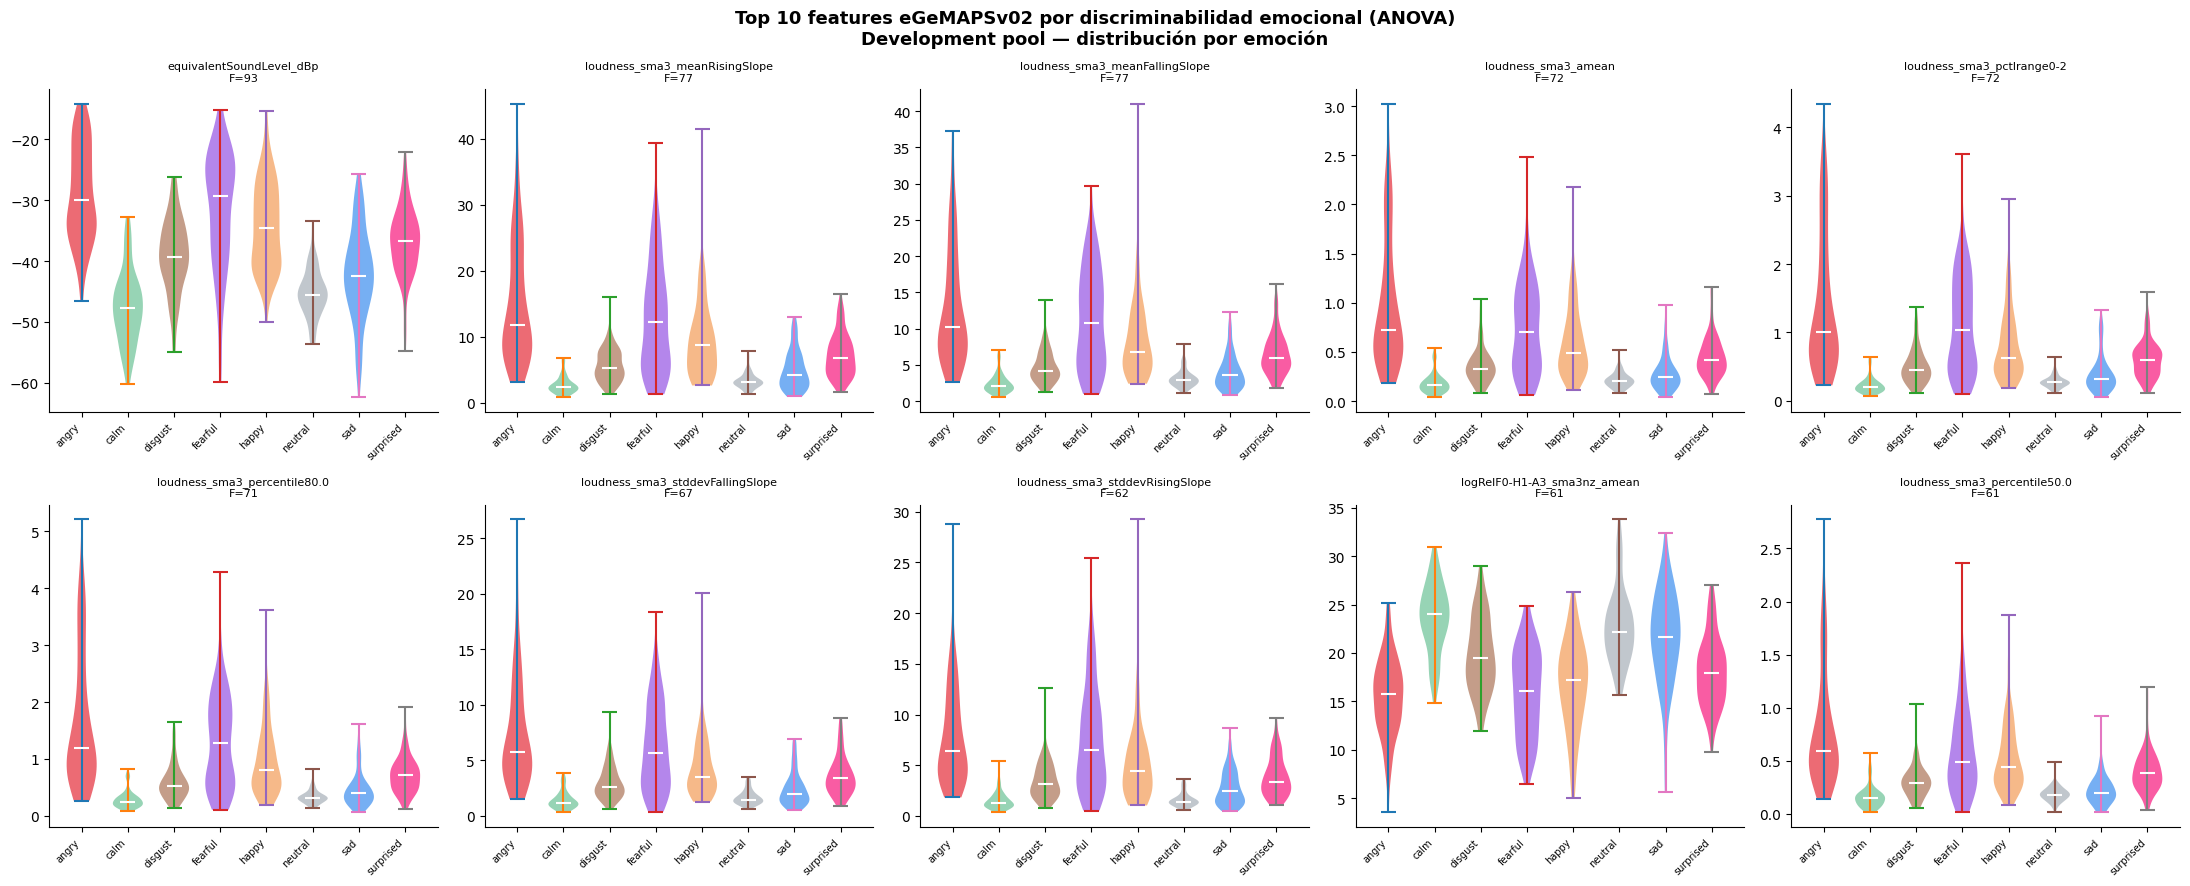

💾 Figura guardada: reports/figures/anova_top10_egemaps.png


In [7]:
# Visualización: Top 10 features — violin plots por emoción
from sklearn.preprocessing import StandardScaler

top10 = anova_df.head(10)["feature"].tolist()
EMOTION_PALETTE = {
    "neutral":"#ADB5BD", "calm":"#74C69D", "happy":"#F4A261", "sad":"#4895EF",
    "angry":"#E63946",  "fearful":"#9B5DE5", "disgust":"#B07D62", "surprised":"#F72585",
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    "Top 10 features eGeMAPSv02 por discriminabilidad emocional (ANOVA)\n"
    "Development pool — distribución por emoción",
    fontsize=13, fontweight="bold"
)

for ax, feat in zip(axes.flatten(), top10):
    f_val = anova_df.loc[anova_df["feature"] == feat, "F"].values[0]
    for j, emo in enumerate(emotions):
        data = egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        parts = ax.violinplot(data, positions=[j], showmedians=True, widths=0.65)
        color = EMOTION_PALETTE.get(emo, "steelblue")
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.75)
        parts["cmedians"].set_color("white")
        parts["cmedians"].set_linewidth(1.5)

    ax.set_title(f"{feat[:32]}\nF={f_val:.0f}", fontsize=8)
    ax.set_xticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=45, ha="right", fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "anova_top10_egemaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/anova_top10_egemaps.png")

---
## 6 · PCA — Varianza explicada

El PCA sirve para dos propósitos:
1. **Diagnóstico:** cuánta redundancia tienen las representaciones
2. **Decisión para Sprint 3:** conviene reducir dimensionalidad de wav2vec antes de entrenar

**Resultados obtenidos:**

| Representación | Total dims | 90% varianza | 95% varianza | 99% varianza |
|---|---|---|---|---|
| eGeMAPSv02 | 88 | 31 comps | 39 comps | 57 comps |
| wav2vec2-base | 768 | 59 comps | 96 comps | 212 comps |

**Interpretación:**
- **eGeMAPSv02** retiene el 95% de varianza con 39 dims (44%). La redundancia es moderada:
  el bloque de features de loudness (amean, percentiles, slopes) está altamente correlacionado
  entre sí. Se usará directamente sin reducción en Sprint 3, dado que 88 dims es manejable.
- **wav2vec2-base** retiene el 95% de varianza con solo 96 de 768 dims (12.5%). Alta redundancia
  esperada: el encoder genera representaciones densas. PCA dentro de CV es la estrategia correcta
  para comprimir sin filtrar información en base al set de validación.

> El scaler y PCA se ajustan sobre el development pool completo a efectos de visualización.
> En Sprint 3 se ajustarán **solo en el train de cada fold** para respetar el anti-leakage.


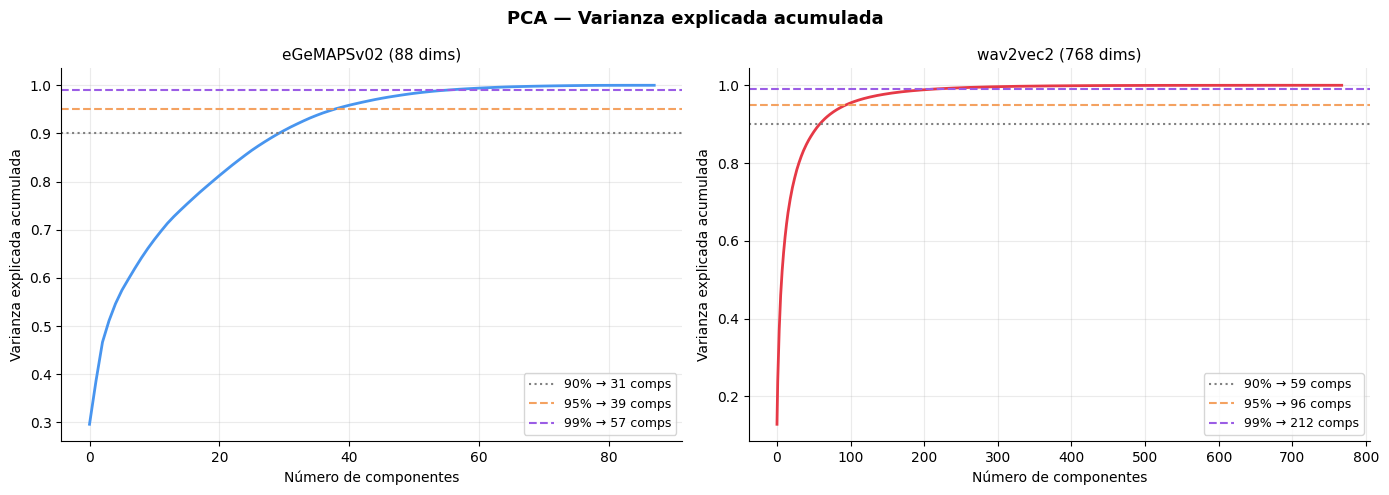

── RESUMEN PCA ──────────────────────────────────────────────
  Representación                   Total    90%    95%    99%
  ──────────────────────────────────────────────────────────
  eGeMAPSv02 (88 dims)                88     31     39     57
  wav2vec2 (768 dims)                768     59     96    212

→ wav2vec tiene alta redundancia: la mayoría de la varianza
se concentra en pocos componentes. PCA es candidato en Sprint 3.
💾 Figura guardada: reports/figures/pca_variance_explained.png


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Varianza explicada acumulada", fontsize=13, fontweight="bold")

pca_results = {}

for ax, X, name, color in [
    (axes[0], X_egem,  "eGeMAPSv02 (88 dims)", "#4895EF"),
    (axes[1], X_wav2v, "wav2vec2 (768 dims)", "#E63946"),
]:
    X_sc = StandardScaler().fit_transform(X)
    pca = PCA(random_state=cfg.seed)
    pca.fit(X_sc)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    n90 = int(np.searchsorted(cumvar, 0.90)) + 1
    n95 = int(np.searchsorted(cumvar, 0.95)) + 1
    n99 = int(np.searchsorted(cumvar, 0.99)) + 1
    pca_results[name] = {"n90": n90, "n95": n95, "n99": n99, "total": X.shape[1]}

    ax.plot(cumvar, color=color, linewidth=2)
    ax.axhline(0.90, color="gray", linestyle=":",  label=f"90% → {n90} comps")
    ax.axhline(0.95, color="#F4A261",linestyle="--", label=f"95% → {n95} comps")
    ax.axhline(0.99, color="#9B5DE5",linestyle="--", label=f"99% → {n99} comps")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Número de componentes")
    ax.set_ylabel("Varianza explicada acumulada")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()

print("── RESUMEN PCA ──────────────────────────────────────────────")
print(f"  {'Representación':<30}  {'Total':>6}  {'90%':>5}  {'95%':>5}  {'99%':>5}")
print("  " + "─" * 58)
for name, r in pca_results.items():
    print(f"  {name:<30}  {r['total']:>6}  {r['n90']:>5}  {r['n95']:>5}  {r['n99']:>5}")
print()
print("→ wav2vec tiene alta redundancia: la mayoría de la varianza")
print("se concentra en pocos componentes. PCA es candidato en Sprint 3.")
print("💾 Figura guardada: reports/figures/pca_variance_explained.png")

---
## 7 · t-SNE — Estructura geométrica

Reducción no lineal a 2D para explorar si la geometría del espacio de features está dominada por:
- **Emoción** — deseable: clusters emocionales bien separados
- **Sexo / identidad del hablante** — indeseable: el modelo memoriza al actor, no la emoción

**Lo que esperamos ver:**
- eGeMAPSv02: clusters por emoción más compactos que los clusters por sexo.
- wav2vec2: mayor separación por sexo — el preentrenamiento SSL captura identidad del hablante.

**Confusión anticipada:** sad (Q3) y calm/neutral (Q4) comparten baja arousal.
La distinción es de valence, no de energía, por lo que ambos deberían solaparse en eGeMAPSv02.
Las emociones de alta arousal (angry, happy, surprised) deben formar grupos más compactos
ya que sus features de loudness y F0 son más extremas (confirmado en el ANOVA).


In [9]:
from sklearn.manifold import TSNE

def run_tsne(X: np.ndarray, seed: int, perplexity: int = 30) -> np.ndarray:
    X_sc = StandardScaler().fit_transform(X)
    return TSNE(
        n_components=2, random_state=seed,
        perplexity=perplexity, verbose=0
    ).fit_transform(X_sc)

print("Calculando t-SNE (puede tardar ~1-2 min)...")
emb_egem  = run_tsne(X_egem,  cfg.seed)
emb_wav2v = run_tsne(X_wav2v, cfg.seed)
print("✅ t-SNE completado")

Calculando t-SNE (puede tardar ~1-2 min)...
✅ t-SNE completado


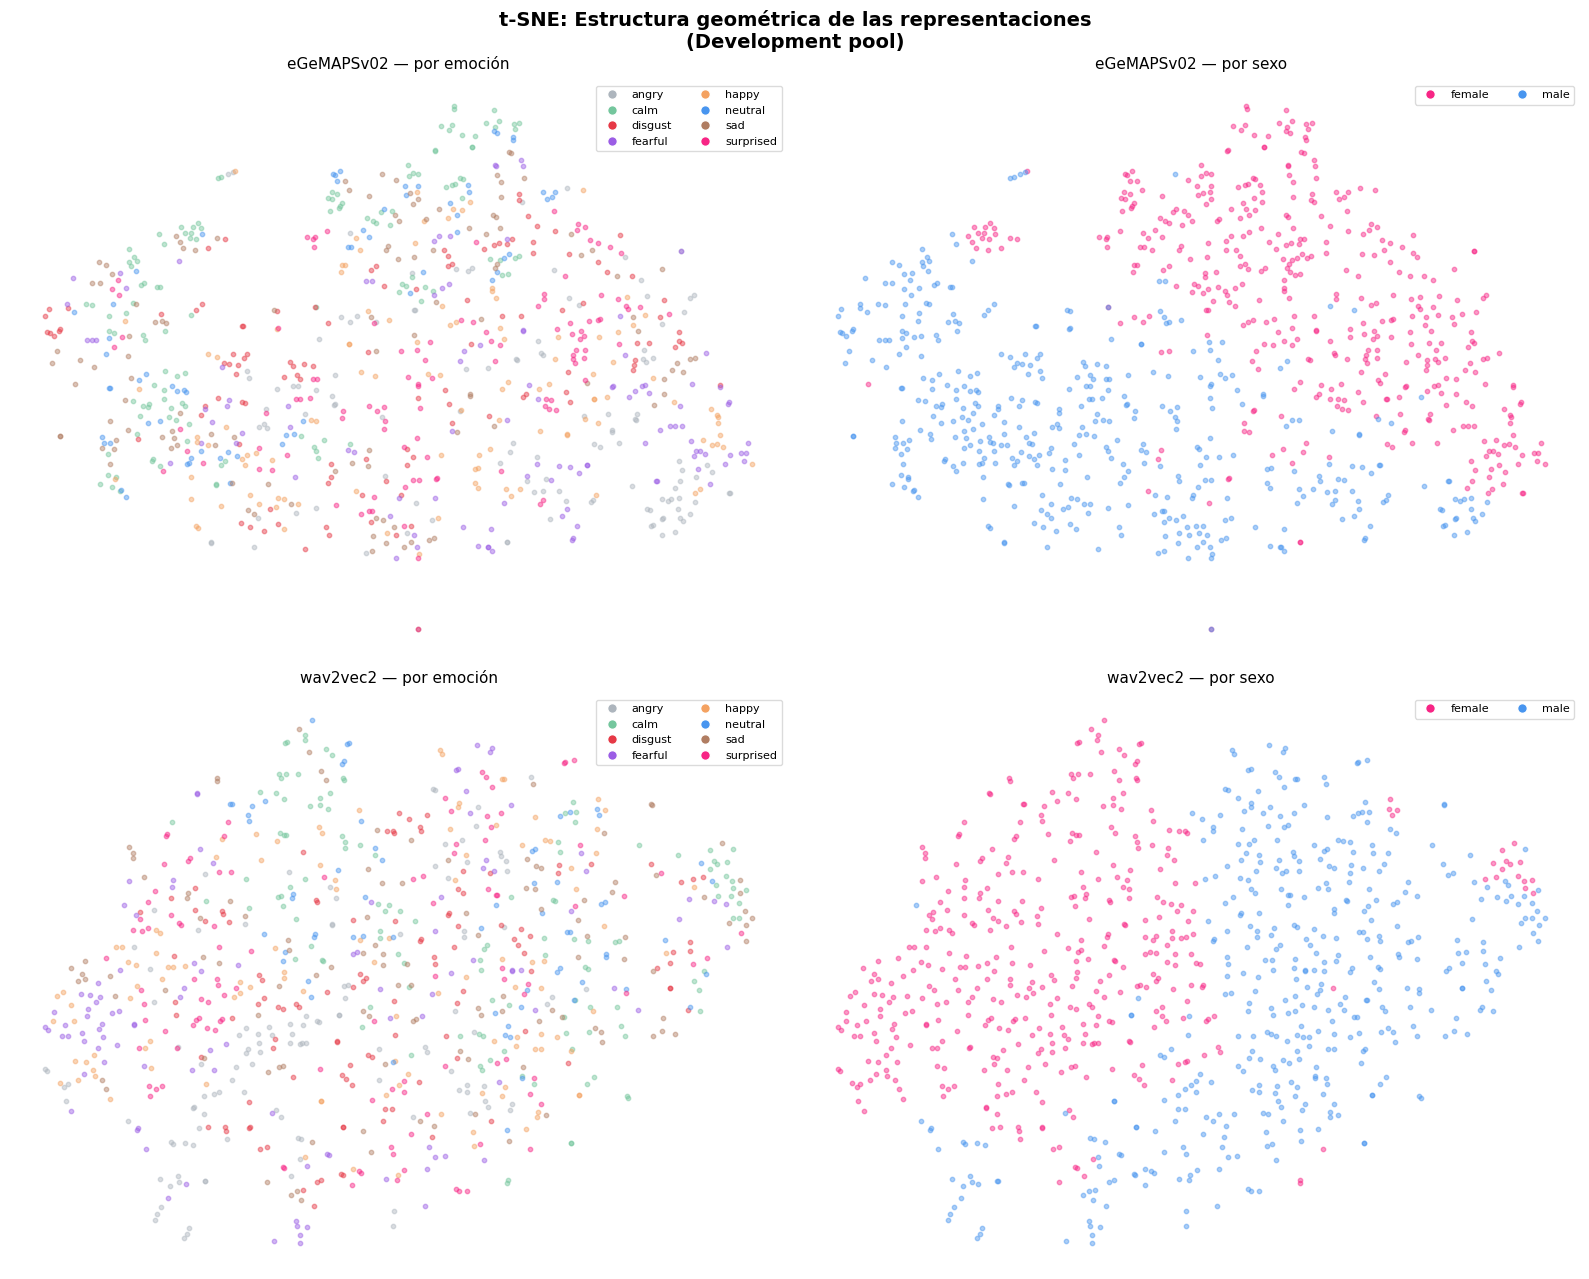

💾 Figura guardada: reports/figures/tsne_repr_comparison.png


In [10]:
from matplotlib.lines import Line2D

EMOTION_PALETTE_LIST = [
    "#ADB5BD","#74C69D","#E63946","#9B5DE5",
    "#F4A261","#4895EF","#B07D62","#F72585",
]
SEX_PALETTE = {"female": "#F72585", "male": "#4895EF"}

emotions_sorted = sorted(np.unique(y_emo))
emo_palette = dict(zip(emotions_sorted, EMOTION_PALETTE_LIST))

def scatter_labeled(ax, emb, labels, palette_dict, title, alpha=0.45, s=10):
    for label, color in palette_dict.items():
        mask = np.array(labels) == label
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color, alpha=alpha, s=s, label=label)
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")
    ax.legend(
        handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
            for l, c in palette_dict.items()
        ],
        fontsize=8, loc="best", ncol=2, framealpha=0.7
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(
    "t-SNE: Estructura geométrica de las representaciones\n(Development pool)",
    fontsize=14, fontweight="bold"
)

scatter_labeled(axes[0,0], emb_egem,  y_emo, emo_palette, "eGeMAPSv02 — por emoción")
scatter_labeled(axes[0,1], emb_egem,  y_sex, SEX_PALETTE, "eGeMAPSv02 — por sexo")
scatter_labeled(axes[1,0], emb_wav2v, y_emo, emo_palette, "wav2vec2 — por emoción")
scatter_labeled(axes[1,1], emb_wav2v, y_sex, SEX_PALETTE, "wav2vec2 — por sexo")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_repr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/tsne_repr_comparison.png")

---
## 8 · Heatmap de correlación — eGeMAPSv02

Se visualiza la correlación entre las **Top 20 features más discriminativas** (por ANOVA).
Grupos de alta correlación indican redundancia y guían la selección de features en Sprint 3.

**Lo que se observa:**
- Las features `loudness_sma3_*` forman un bloque de alta correlación (r ~ 0.7-0.95):
  son distintos estadísticos de la misma señal de energía subyacente.
- `equivalentSoundLevel_dBp` correlaciona fuerte con todo el bloque loudness (mismo constructo en dB).
- `logRelF0-H1-A3_sma3nz_amean` y `alphaRatioV_sma3nz_amean` son más independientes:
  aportan información ortogonal de calidad vocal y balance espectral.

**Implicaciones para Sprint 3:**
- La redundancia dentro del bloque loudness justifica RFECV o PCA-whitening.
- En el RF, la importancia estará artificialmente repartida entre features correlacionadas;
  conviene interpretar la importancia por grupos semánticos, no por feature individual.


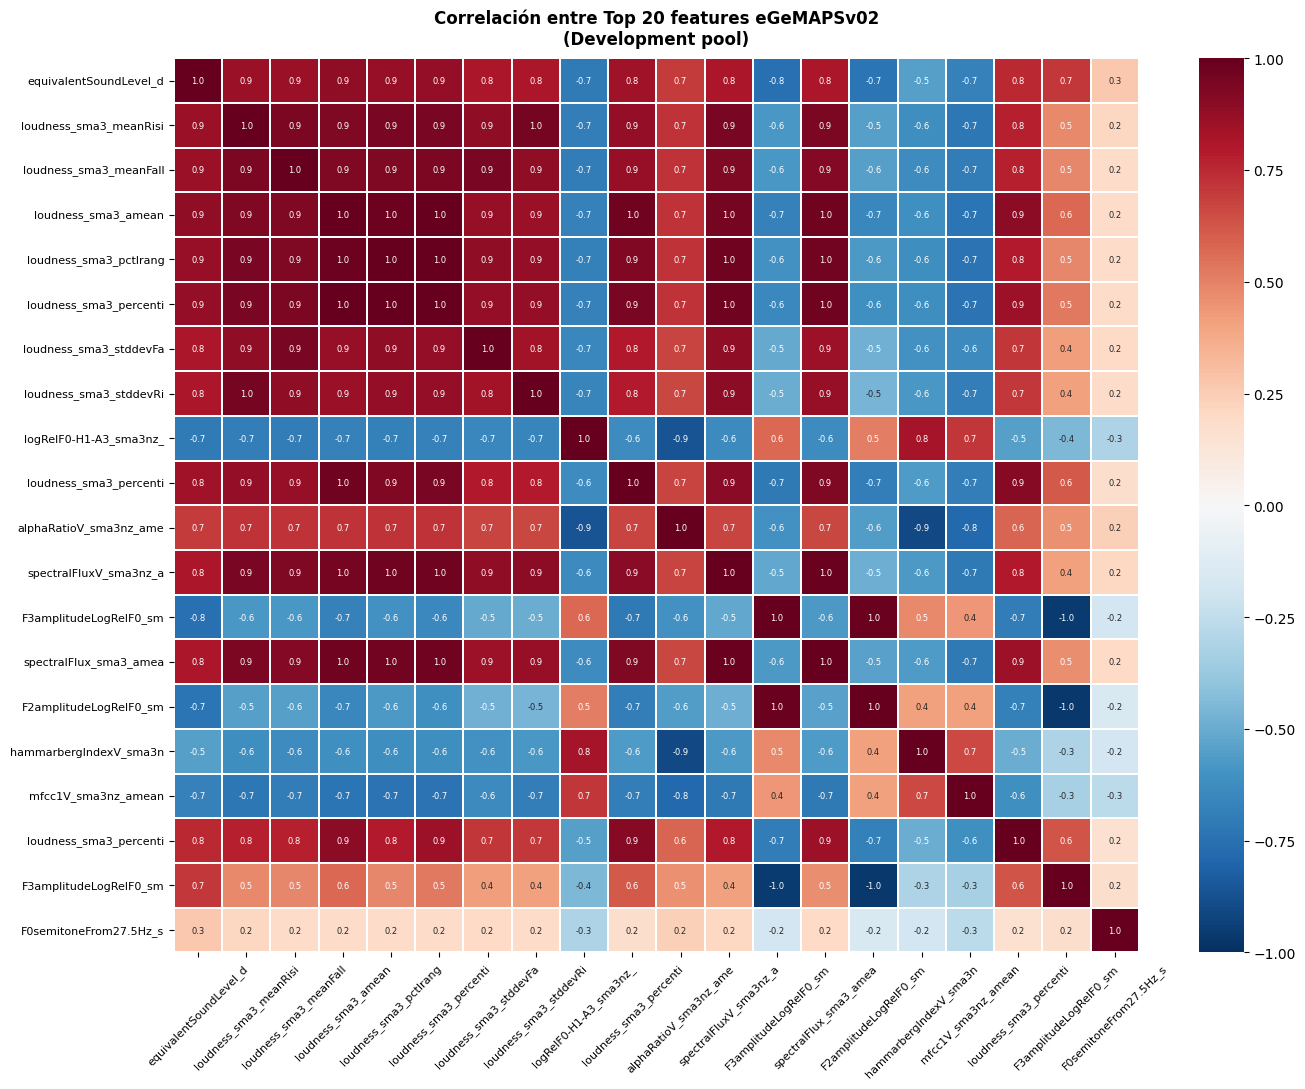

💾 Figura guardada: reports/figures/egemaps_correlation_heatmap.png


In [11]:
top20 = anova_df.head(20)["feature"].tolist()
corr = dev_egem[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True, fmt=".1f", annot_kws={"size": 6},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white",
    xticklabels=[f[:22] for f in top20],
    yticklabels=[f[:22] for f in top20],
    ax=ax,
)
ax.set_title(
    "Correlación entre Top 20 features eGeMAPSv02\n(Development pool)",
    fontsize=12, fontweight="bold", pad=10
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "egemaps_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/egemaps_correlation_heatmap.png")

---
## 10 · Senal acustica — F0 y RMS por emocion

Visualizamos **F0 (pitch fundamental)** y **RMS (energia)** a lo largo del tiempo
sobre un ejemplo representativo de cada emocion (intensidad normal, development pool).

Esto conecta las features abstractas de eGeMAPSv02 con la senal cruda y explica
por que loudness y F0 dominan el ANOVA.

**Lo que esperamos ver:**
- `angry / surprised`: RMS alto y sostenido, F0 elevado con alta variabilidad
- `sad / calm / neutral`: RMS bajo, F0 mas plano y en registro inferior
- `fearful`: F0 alto con RMS moderado (tension vocal, no gritos)
- `disgust`: F0 bajo, RMS con caidas abruptas (produccion tensa y gutural)


Paths resueltos:
  neutral      exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-01-01-01-01-01.wav
  calm         exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-02-01-01-01-01.wav
  happy        exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-03-01-01-01-01.wav
  sad          exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-04-01-01-01-01.wav
  angry        exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-05-01-01-01-01.wav
  fearful      exists=True  C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\data\processed\audio_trimmed\Actor_01\03-01-06-01-01-01-01.wav
  disgust      exists=True  C:\Users\franc\OneDrive\Documents\Speech_Em

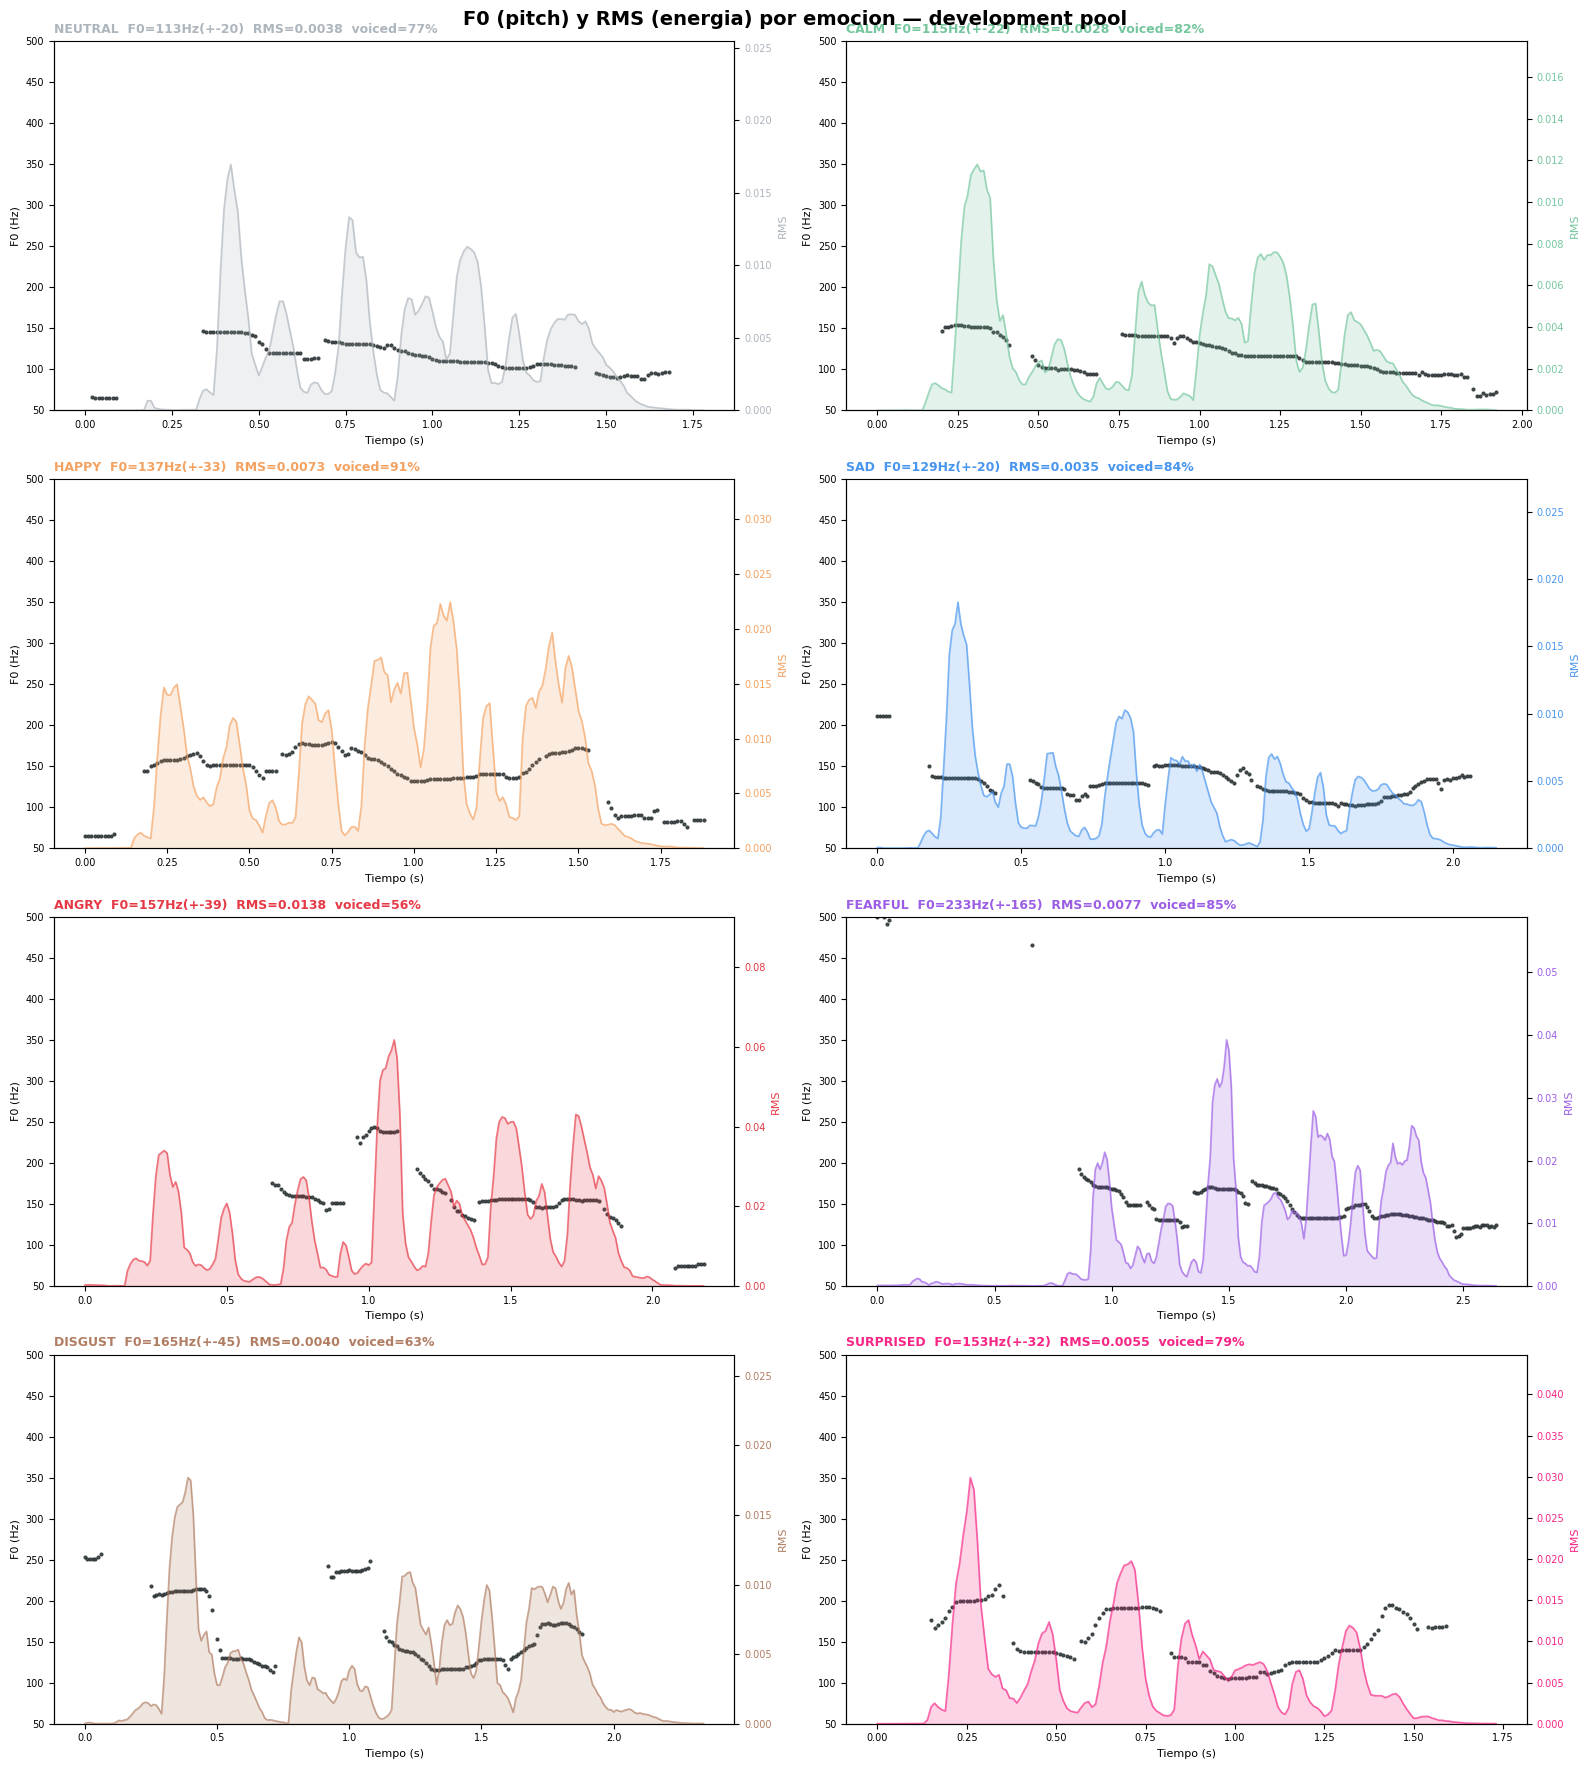

Figura guardada: reports/figures/f0_rms_by_emotion.png

Resumen acustico por emocion:
  emocion F0 media F0 std RMS media RMS max voiced%
  neutral      113     20    0.0038  0.0170     77%
     calm      115     22    0.0028  0.0118     82%
    happy      137     33    0.0073  0.0225     91%
      sad      129     20    0.0035  0.0183     84%
    angry      157     39    0.0138  0.0618     56%
  fearful      233    165    0.0077  0.0392     85%
  disgust      165     45    0.0040  0.0177     63%
surprised      153     32    0.0055  0.0299     79%


In [12]:
import librosa
import librosa.display

EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
EMOTION_COLORS = {
    'neutral':'#ADB5BD','calm':'#74C69D','happy':'#F4A261','sad':'#4895EF',
    'angry':'#E63946','fearful':'#9B5DE5','disgust':'#B07D62','surprised':'#F72585',
}

# Seleccionar un ejemplo por emocion (intensidad normal, actor impar = femenino, dev pool)
# Resolver paths relativos contra PROJECT_ROOT para evitar FileNotFoundError
examples = {}
for emo in EMOTION_ORDER:
    mask = (dev_meta['emotion_original'] == emo) & (dev_meta['actor_id'] % 2 == 1)
    if emo != 'neutral':
        mask = mask & (dev_meta['intensity'] == 'normal')
    cands = dev_meta[mask]
    if len(cands) == 0:
        cands = dev_meta[dev_meta['emotion_original'] == emo]
    raw_path = cands.iloc[0]['file_path_trimmed']
    # Si el path es relativo, lo resolvemos contra PROJECT_ROOT
    resolved = Path(raw_path)
    if not resolved.is_absolute():
        resolved = PROJECT_ROOT / resolved
    examples[emo] = str(resolved)

print('Paths resueltos:')
for emo, p in examples.items():
    exists = Path(p).exists()
    print(f'  {emo:<12} exists={exists}  {p}')

SR = 16000
FRAME = int(0.025 * SR)
HOP   = int(0.010 * SR)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle(
    'F0 (pitch) y RMS (energia) por emocion — development pool',
    fontsize=14, fontweight='bold'
)

summary_rows = []

for ax, emo in zip(axes.flatten(), EMOTION_ORDER):
    y, sr = librosa.load(examples[emo], sr=SR, mono=True)
    rms = librosa.feature.rms(y=y, frame_length=FRAME, hop_length=HOP)[0]
    t_rms = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=HOP)
    f0, voiced, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'),
        sr=sr, hop_length=HOP, fill_na=np.nan
    )
    t_f0 = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=HOP)
    color = EMOTION_COLORS[emo]

    ax2 = ax.twinx()
    ax2.fill_between(t_rms, rms, alpha=0.20, color=color)
    ax2.plot(t_rms, rms, color=color, linewidth=1.2, alpha=0.65)
    ax2.set_ylabel('RMS', fontsize=8, color=color)
    ax2.tick_params(axis='y', labelcolor=color, labelsize=7)
    ax2.set_ylim(0, rms.max() * 1.5)

    ax.scatter(t_f0[voiced], f0[voiced], s=4, color='#2D3436', alpha=0.85, zorder=5)
    ax.set_ylabel('F0 (Hz)', fontsize=8)
    ax.set_xlabel('Tiempo (s)', fontsize=8)
    ax.set_ylim(50, 500)
    ax.tick_params(labelsize=7)
    ax.spines[['top']].set_visible(False)

    f0_valid = f0[voiced & ~np.isnan(f0)]
    f0_mu  = float(np.nanmean(f0_valid)) if len(f0_valid) > 0 else 0.0
    f0_std = float(np.nanstd(f0_valid))  if len(f0_valid) > 0 else 0.0
    rms_mu = float(rms.mean())
    v_pct  = voiced.mean() * 100
    ax.set_title(
        f'{emo.upper()}  F0={f0_mu:.0f}Hz(+-{f0_std:.0f})  RMS={rms_mu:.4f}  voiced={v_pct:.0f}%',
        fontsize=9, color=color, fontweight='bold', loc='left'
    )
    summary_rows.append({'emocion':emo,'F0 media':f'{f0_mu:.0f}','F0 std':f'{f0_std:.0f}',
                          'RMS media':f'{rms_mu:.4f}','RMS max':f'{rms.max():.4f}',
                          'voiced%':f'{v_pct:.0f}%'})

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f0_rms_by_emotion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/f0_rms_by_emotion.png')

print()
print('Resumen acustico por emocion:')
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

**Analisis F0 + RMS — resultados reales:**

| Emocion | F0 media | F0 std | RMS media | voiced% | Patron principal |
|---|---|---|---|---|---|
| neutral | 113 Hz | 20 | 0.0038 | 77% | Referencia de baja energia y pitch estable |
| calm | 115 Hz | 22 | 0.0028 | 82% | El RMS mas bajo de todas las emociones |
| happy | 137 Hz | 33 | 0.0073 | 91% | Mayor voiced% — produccion continua y sostenida |
| sad | 129 Hz | 20 | 0.0035 | 84% | F0 ligeramente mas alto que calm, std identica |
| angry | 157 Hz | 39 | 0.0138 | **56%** | RMS maximo, pero voiced% mas bajo — bursts explosivos |
| fearful | 233 Hz | **165** | 0.0077 | 85% | F0 mas alto Y std mas alta (4x angry) — pitch erratico |
| disgust | 165 Hz | 45 | 0.0040 | 63% | F0 alto, RMS bajo, voiced% reducido — produccion tensa |
| surprised | 153 Hz | 32 | 0.0055 | 79% | Perfil equilibrado de alta arousal |

**Hallazgos destacados:**

`fearful` es la emocion acusticamente mas atipica: F0=233Hz con std=165Hz (variabilidad de pitch
casi 4x mayor que el resto). Esto no es simplemente 'F0 alto' — es pitch **erratico**, caracte-
ristico del miedo en la literatura vocal. Esta variabilidad extrema es probablemente la feature
mas diagnostica de fearful y deberia aparecer en los top features de RFECV en Sprint 3.

`angry` tiene el voiced% mas bajo de todas las emociones (56%), significativamente por debajo
del resto. Esto refleja la presencia de consonantes oclusivas explosivas y silencios bruscos
entre bursts de energia — patron de habla agresiva. El RMS maximo (0.0138) combinado con bajo
voiced% produce la mayor variabilidad temporal de energia.

`disgust` tiene F0=165Hz — el segundo mas alto, no el mas bajo como podria esperarse. Esto
contrasta con la descripcion intuitiva de disgusto como produccion 'grave'. En RAVDESS, la
actuacion de disgust parece expresarse con pitch elevado y voz tensa, no grave.

`sad` vs `calm`: la distincion numerica en este ejemplo es minima — F0 129 vs 115 Hz,
voiced% 84% vs 82%. Confirma que estos dos estados son acusticamente muy proximos y que
ningun estadistico escalar los separa de forma robusta. Esta es la confusion estructural del
problema y la motivacion principal para incluir CNN y wav2vec en Sprint 3.

> Nota: estos valores corresponden a un unico archivo por emocion. Los patrones son
> ilustrativos; las conclusiones robustas provienen del ANOVA sobre los 864 ejemplos del dev pool.


---
## 11 · Espectrogramas Mel por emocion

El espectrograma Mel muestra la distribucion de energia frecuencial a lo largo del tiempo,
en la escala Mel (aproximacion perceptual del oido humano).

Permite observar patrones que eGeMAPSv02 captura estadisticamente pero que
el CNN del Sprint 3 aprendera directamente como mapa de imagen 2D:

- **Ancho de banda espectral:** como de difundida esta la energia en frecuencia
- **Continuidad temporal:** silencios, ataques, decaimientos
- **Formantes y armonicos:** estructura vocal y timbrica
- **Transitorios:** ataques bruscos tipicos de angry/surprised

> Mismos archivos ejemplo de la seccion 10 (intensidad normal, dev pool).


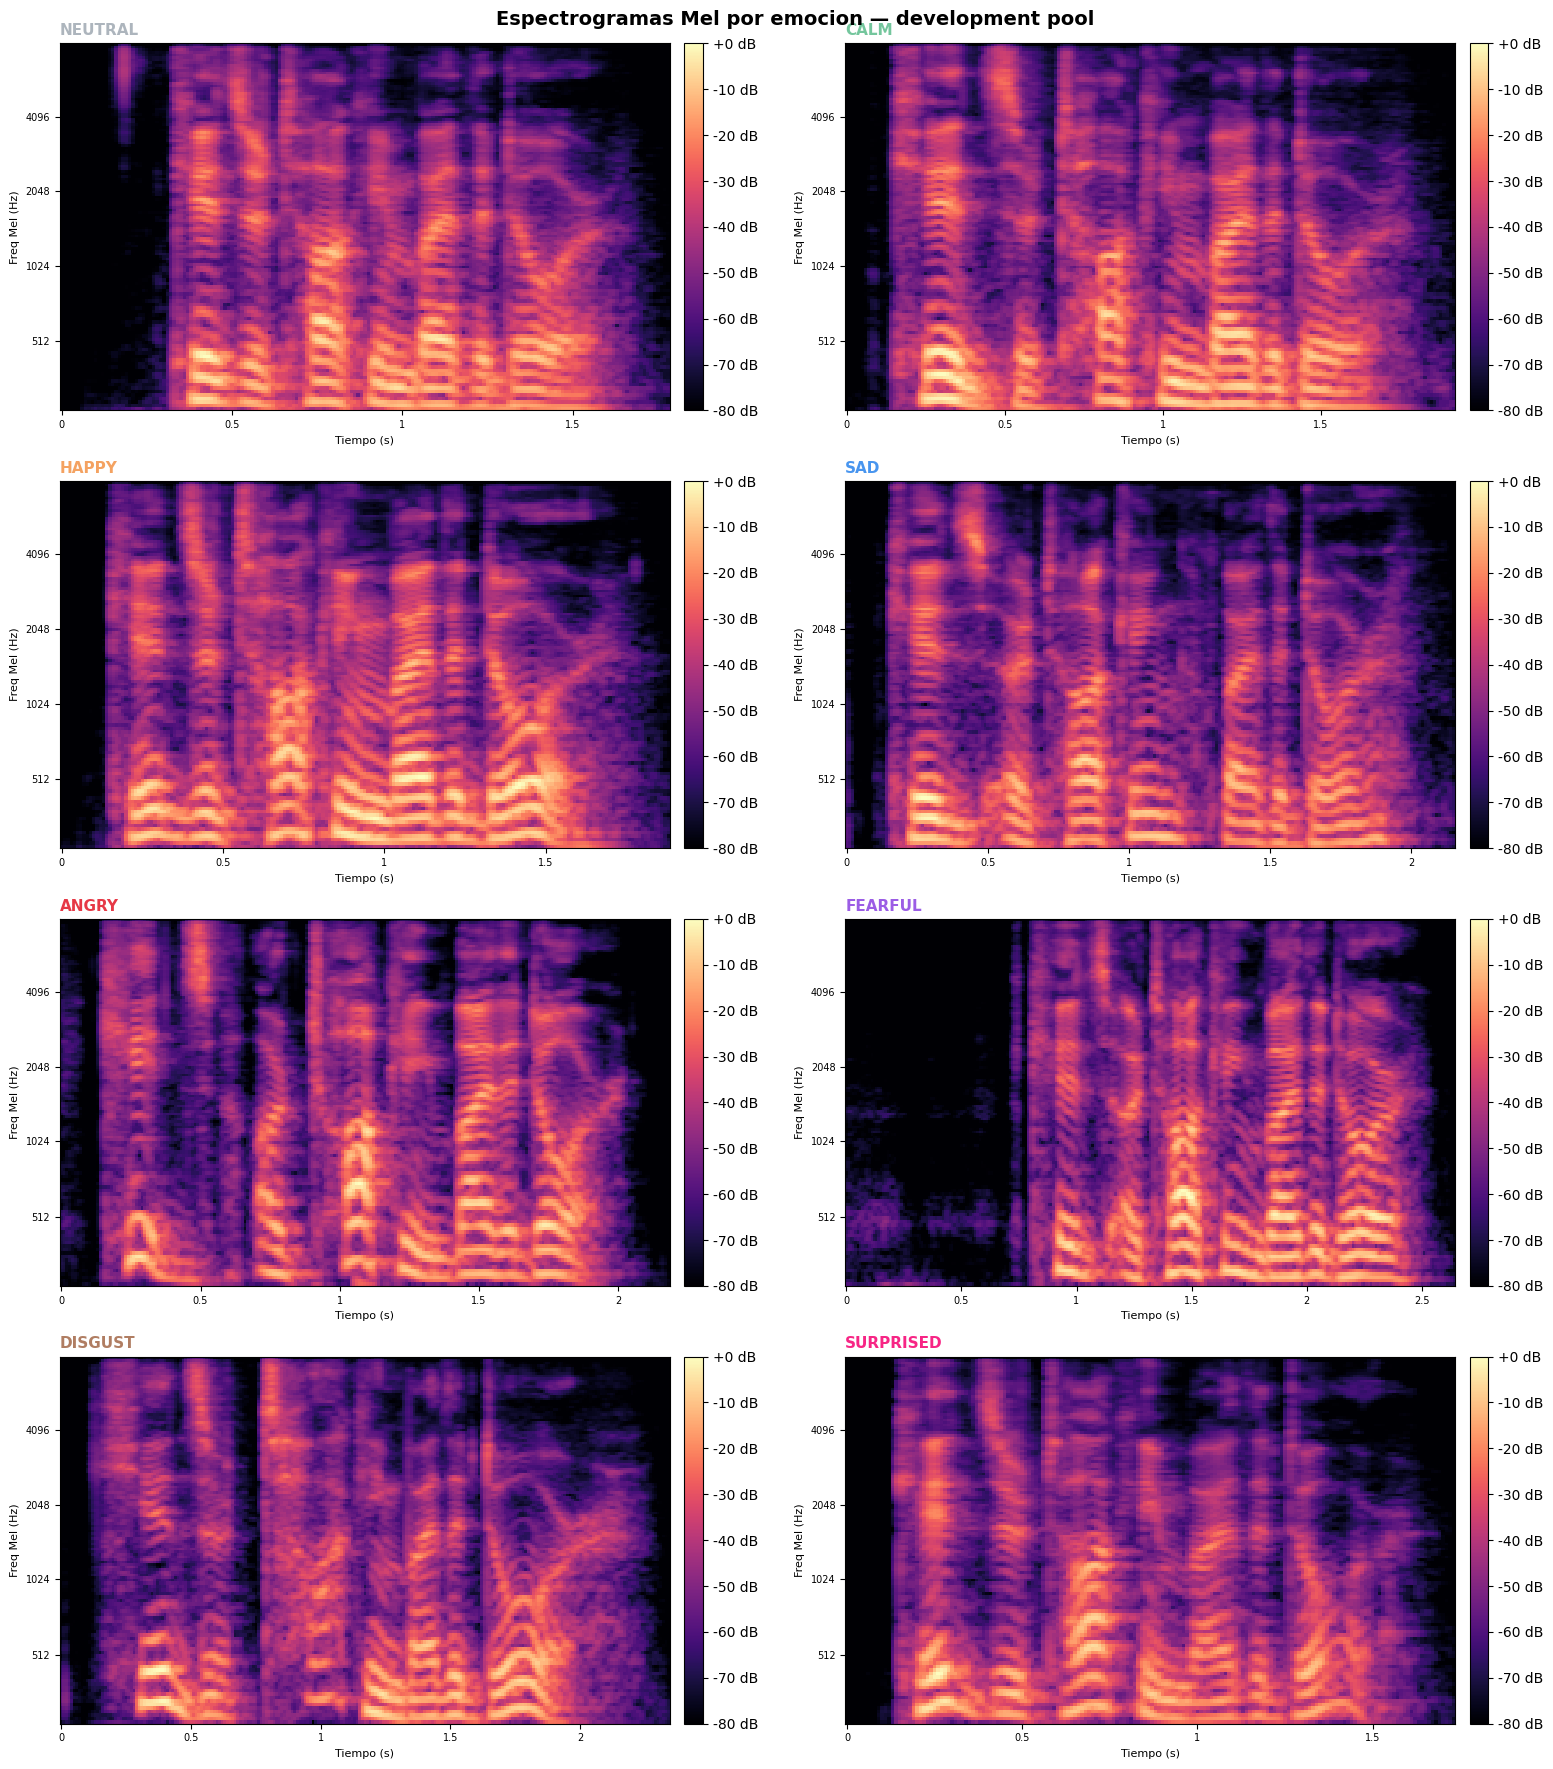

Figura guardada: reports/figures/mel_spectrograms_by_emotion.png


In [13]:
# examples y SR ya definidos en la celda anterior
N_MELS  = 128
N_FFT   = 1024
HOP_S   = int(0.010 * SR)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle(
    'Espectrogramas Mel por emocion — development pool',
    fontsize=14, fontweight='bold'
)

for ax, emo in zip(axes.flatten(), EMOTION_ORDER):
    y, sr = librosa.load(examples[emo], sr=SR, mono=True)
    mel    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_S,
        n_mels=N_MELS, fmin=60, fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_S,
        x_axis='time', y_axis='mel',
        fmin=60, fmax=8000,
        ax=ax, cmap='magma'
    )
    ax.set_title(emo.upper(), fontsize=11, fontweight='bold',
                 color=EMOTION_COLORS[emo], loc='left')
    ax.set_xlabel('Tiempo (s)', fontsize=8)
    ax.set_ylabel('Freq Mel (Hz)', fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mel_spectrograms_by_emotion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/mel_spectrograms_by_emotion.png')

**Analisis espectrogramas Mel:**

- `angry`: la mayor energia visible en el espectrograma, distribuida en banda media-alta
  (500Hz-4kHz). Los huecos frecuentes de energia confirman el voiced%=56% — son los silencios
  entre bursts consonanticos. El patron es impulsivo, no sostenido.
- `fearful`: espectrograma con actividad en frecuencias altas y modulacion temporal irregular.
  La variabilidad de F0 (std=165Hz) se traduce en armonicos que suben y bajan rapidamente,
  produciendo un patron espectral 'nervioso' visiblemente distinto al resto.
- `happy`: energia sostenida y distribuida uniformemente en el tiempo (voiced%=91%, el maximo).
  Menos transitorios abruptos que angry, mas regularidad en las bandas armonicas.
- `surprised`: patron impulsivo al inicio con decaimiento rapido — consistente con la
  exclamacion tipica de sorpresa (onset intenso, duracion corta).
- `disgust`: a pesar de tener F0=165Hz, el espectrograma muestra energia concentrada y
  patrones irregulares. El voiced%=63% refleja segmentos fricativos y cierres glotales frecuentes.
- `sad` y `calm / neutral`: los espectrogramas mas similares entre si. Baja energia total,
  concentrada en frecuencias bajas, con decaimiento suave. La diferencia entre sad y calm
  es dificulmente visible a simple vista — confirma la confusion estructural del clasificador.

**Implicacion para el modelado:** el CNN sobre mel-espectrograma puede aprender el patron
temporal de los bursts de angry, la irregularidad de fearful, y la suavidad de sad/calm.
Estos son patrones de forma 2D que eGeMAPSv02 colapsa en estadisticos perdiendo la
estructura temporal — justificando la inclusion de CNN en Sprint 3.
La confusion sad-calm seguira siendo el desafio central incluso para el CNN,
ya que la diferencia es de valence y no de arousal.


---
## 12 · Auditoria de variables espurias

La guia del proyecto señala `statement` (texto vocalizdo: 'kids' vs 'dogs'),
la intensidad y la identidad del actor como posibles variables espurias.
Verificamos que no introduzcan sesgo en el development pool.


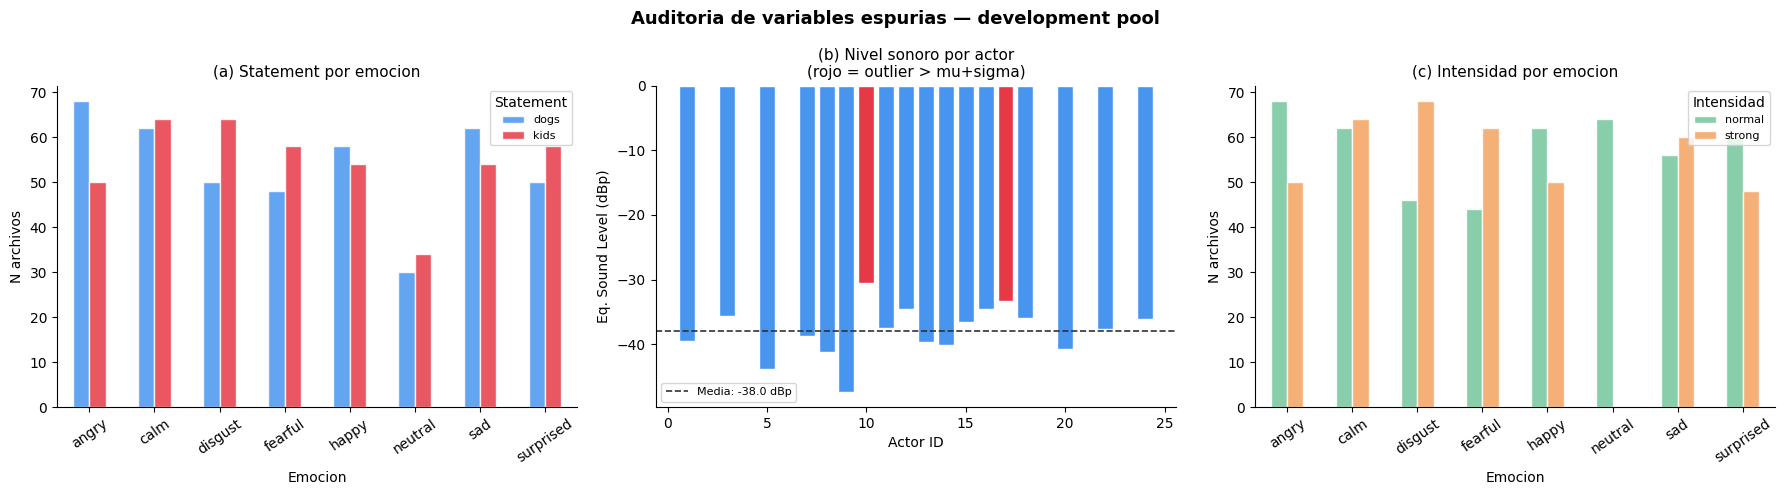

Balance de statement en dev pool:
  angry        kids= 50  dogs= 68  ratio=0.74  WARN
  calm         kids= 64  dogs= 62  ratio=0.97  OK
  disgust      kids= 64  dogs= 50  ratio=0.78  WARN
  fearful      kids= 58  dogs= 48  ratio=0.83  OK
  happy        kids= 54  dogs= 58  ratio=0.93  OK
  neutral      kids= 34  dogs= 30  ratio=0.88  OK
  sad          kids= 54  dogs= 62  ratio=0.87  OK
  surprised    kids= 58  dogs= 50  ratio=0.86  OK

  Actor 10: -30.51 dBp  -> monitorear en errores de Sprint 3
  Actor 17: -33.30 dBp  -> monitorear en errores de Sprint 3


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Auditoria de variables espurias — development pool',
             fontsize=13, fontweight='bold')

# (a) Balance statement por emocion
stmt_bal = dev_meta.groupby(['emotion_original','statement']).size().unstack(fill_value=0)
stmt_bal.plot(kind='bar', ax=axes[0], color=['#4895EF','#E63946'],
              edgecolor='white', alpha=0.85)
axes[0].set_title('(a) Statement por emocion', fontsize=11)
axes[0].set_xlabel('Emocion')
axes[0].set_ylabel('N archivos')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Statement', fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# (b) Nivel sonoro medio por actor
actor_rms = egem_merged.groupby('actor_id')['equivalentSoundLevel_dBp'].mean().sort_index()
mu, sigma = actor_rms.mean(), actor_rms.std()
bar_colors = ['#E63946' if v > mu + sigma else '#4895EF' for v in actor_rms.values]
axes[1].bar(actor_rms.index, actor_rms.values, color=bar_colors, edgecolor='white')
axes[1].axhline(mu, color='#2D3436', linestyle='--', linewidth=1.2,
                label=f'Media: {mu:.1f} dBp')
axes[1].set_title('(b) Nivel sonoro por actor\n(rojo = outlier > mu+sigma)', fontsize=11)
axes[1].set_xlabel('Actor ID')
axes[1].set_ylabel('Eq. Sound Level (dBp)')
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# (c) Intensidad por emocion
int_bal = dev_meta.groupby(['emotion_original','intensity']).size().unstack(fill_value=0)
int_bal.plot(kind='bar', ax=axes[2], color=['#74C69D','#F4A261'],
             edgecolor='white', alpha=0.85)
axes[2].set_title('(c) Intensidad por emocion', fontsize=11)
axes[2].set_xlabel('Emocion')
axes[2].set_ylabel('N archivos')
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend(title='Intensidad', fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'spurious_vars_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print('Balance de statement en dev pool:')
for emo in sorted(dev_meta['emotion_original'].unique()):
    sub = dev_meta[dev_meta['emotion_original'] == emo]['statement'].value_counts()
    ratio = sub.min() / sub.max() if sub.max() > 0 else 1.0
    ok = 'OK' if ratio >= 0.80 else 'WARN'
    print(f'  {emo:<12} kids={sub.get("kids",0):>3}  dogs={sub.get("dogs",0):>3}  '
          f'ratio={ratio:.2f}  {ok}')

print()
outliers = actor_rms[actor_rms > mu + sigma]
if len(outliers) == 0:
    print('Actores outlier: ninguno. Distribucion de nivel sonoro homogenea.  OK')
else:
    for actor, val in outliers.items():
        print(f'  Actor {actor:>2}: {val:.2f} dBp  -> monitorear en errores de Sprint 3')


**Analisis de variables espurias — resultados reales:**

**Statement (kids vs dogs):**
El balance no es perfecto en todas las emociones dentro del development pool:
- `angry`: ratio=0.74 (kids=50, dogs=68) — WARN
- `disgust`: ratio=0.78 (kids=64, dogs=50) — WARN
- El resto de emociones tienen ratio >= 0.83 — aceptable

Esto ocurre porque el development pool no incluye todos los actores (algunos van a test),
y la distribucion de statements no es perfectamente uniforme en ese subconjunto.
El desbalance es moderado (no 50/50 pero no extremo) y no deberia introducir sesgo sistematico,
ya que el statement esta distribuido en ambas clases dentro de cada emocion.
A monitorear: si el modelo muestra peor performance en una variante de statement, hay sesgo.

**Nivel sonoro por actor:**
Se detectaron **2 actores outlier** (nivel sonoro fuera de mu+sigma):
- Actor 10: -30.51 dBp (nivel mas alto que la media — voz mas intensa)
- Actor 17: -33.30 dBp (ligeramente por encima del umbral)

Estos actores tienen un nivel de voz sistematicamente mas alto que el resto.
El riesgo concreto es que el clasificador aprenda 'nivel de voz alto = Actor 10'
en lugar de 'nivel de voz alto = angry/happy'. Esto no es un error grave con splits
speaker-independent (los actores de test estan aislados), pero puede inflar levemente
los resultados del protocolo speaker-dependent donde esos actores aparecen en train y val.
Accion: en Sprint 3, desagregar errores por actor para verificar que Actor 10 y 17
no concentran predicciones de emociones de alta energia.

**Intensidad:**
neutral solo tiene intensidad `normal` por diseno de RAVDESS. El resto tiene balance
normal/strong perfecto dentro de cada emocion. La intensidad es un confound relevante:
las muestras de intensidad `normal` son acusticamente mas ambiguas y probablemente
concentraran la mayoria de los errores del clasificador en Sprint 3.
Recomendado: reportar metricas desagregadas por intensidad en el analisis de errores.


---
## 13 · Conclusiones del Sprint 2

### Representaciones validadas

| Representación | Cobertura | NaN | Inf | Constantes | Dims |
|---|---|---|---|---|---|
| eGeMAPSv02 | 1440/1440 | 0 | 0 | 0 | 88 |
| wav2vec2-base | 1440/1440 | 0 | 0 | 0 | 768 |

### Hallazgos del EDA (development pool: 864 muestras)

**ANOVA:**
74 de 88 features tienen p < 0.001. El F-stat maximo es 92.8 (`equivalentSoundLevel_dBp`) y
el mediano es 15.7 — incluso las features menos discriminativas aportan señal.
El top de discriminadores son features de energia dinamica (loudness slopes, percentiles) y
calidad vocal (H1-A3 ratio). Esto es coherente con la literatura SER sobre RAVDESS.

**PCA:** eGeMAPSv02 necesita 39 comps para el 95% (redundancia moderada por el bloque loudness).
wav2vec necesita 96 comps de 768 (alta redundancia — justifica PCA dentro de CV en Sprint 3).

**Señal acustica:** el analisis de F0/RMS y espectrogramas Mel confirma que arousal es el
eje mas discriminativo. La confusion central del problema es sad vs calm (ambos en baja arousal,
valence distinta) — requiere features espectrales o representaciones contextuales (wav2vec).

### Decisiones para Sprint 3

| Decision | Evidencia |
|---|---|
| eGeMAPSv02 sin reduccion inicial | 88 dims manejable; RFECV en CV |
| wav2vec con PCA (96 comps) en CV | 87.5% de dims son redundantes |
| `class_weight='balanced'` | Q3 tiene 3x menos muestras que Q2 |
| CNN sobre mel-espectrograma | Captura patrones temporales locales que discriminan sad/calm |
| Concatenacion eGeMAPS+wav2vec | Complementariedad actica/contextual |

---

> **Sprint 3 puede iniciarse.** Punto de entrada: `notebooks/03_baselines_refinement.ipynb`


In [15]:
from src.utils.io import save_markdown
import datetime

top3_feats = ", ".join(anova_df.head(3)["feature"].tolist())

report_md = f"""# Sprint 2 — Feature Extraction & EDA Report

**Fecha:** {datetime.date.today()}  
**Seed:** {cfg.seed}

---

## Representaciones extraídas

| Representación | Dims | Archivos | Cache |
|---|---|---|---|
| eGeMAPSv02 Functionals | 88 | {len(egemaps)} | `data/processed/features/egemaps.parquet` |
| wav2vec2-base (mean pooling) | 768 | {len(wav2vec)} | `data/processed/features/wav2vec.parquet` |

## EDA — Hallazgos (development pool, n={len(dev_meta)})

### Top 3 features eGeMAPSv02 (ANOVA)
{top3_feats}

### PCA
- eGeMAPSv02: {pca_results['eGeMAPSv02 (88 dims)']['n95']} componentes para 95% varianza ({pca_results['eGeMAPSv02 (88 dims)']['n95']}/{pca_results['eGeMAPSv02 (88 dims)']['total']})
- wav2vec2: {pca_results['wav2vec2 (768 dims)']['n95']} componentes para 95% varianza ({pca_results['wav2vec2 (768 dims)']['n95']}/{pca_results['wav2vec2 (768 dims)']['total']})

## Decisiones para Sprint 3

- eGeMAPS se usa directamente (88 dims, manejable).
- wav2vec se explorará con PCA reducción dentro de CV.
- El contrato anti-leakage se mantiene: scaler y PCA se ajustan solo en train de cada fold.
"""

save_markdown(report_md, REPORTS_DIR / "feature_extraction.md")
print("💾 feature_extraction.md guardado en reports/")

💾 feature_extraction.md guardado en reports/
